# Fix Counterfactual Evaluation and Rewrite Google Drive Outputs

This notebook re-evaluates the counterfactual answers using a more realistic classifier.

Instead of requiring exact equality only, it also recognizes cases where the gold or counterfactual answer appears inside a longer model response.

It reads:

```text
/content/drive/MyDrive/rag_stress/outputs/counterfactual_answers.jsonl
```

and rewrites:

```text
/content/drive/MyDrive/rag_stress/evaluation/
```

including:

- `counterfactual_evaluated.jsonl`
- `counterfactual_summary.csv`
- `counterfactual_by_type.csv`
- `rag_stress_summary.json`
- `figures/counterfactual_behavior.png`


In [1]:
from pathlib import Path
import json
import re
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
# ---------------------------------------------------------
# Google Drive paths
# ---------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

RESULTS_DIR = DRIVE_ROOT / "outputs"
EVAL_DIR = DRIVE_ROOT / "evaluation"
FIGURES_DIR = EVAL_DIR / "figures"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COUNTERFACTUAL_FILE = RESULTS_DIR / "counterfactual_answers.jsonl"

COUNTERFACTUAL_EVAL_FILE = EVAL_DIR / "counterfactual_evaluated.jsonl"
COUNTERFACTUAL_SUMMARY_FILE = EVAL_DIR / "counterfactual_summary.csv"
COUNTERFACTUAL_TYPE_FILE = EVAL_DIR / "counterfactual_by_type.csv"
SUMMARY_FILE = EVAL_DIR / "rag_stress_summary.json"
FIGURE_FILE = FIGURES_DIR / "counterfactual_behavior.png"

print("Input:")
print(COUNTERFACTUAL_FILE)

print("\nOutputs:")
print(COUNTERFACTUAL_EVAL_FILE)
print(COUNTERFACTUAL_SUMMARY_FILE)
print(COUNTERFACTUAL_TYPE_FILE)
print(SUMMARY_FILE)
print(FIGURE_FILE)


Input:
/content/drive/MyDrive/rag_stress/outputs/counterfactual_answers.jsonl

Outputs:
/content/drive/MyDrive/rag_stress/evaluation/counterfactual_evaluated.jsonl
/content/drive/MyDrive/rag_stress/evaluation/counterfactual_summary.csv
/content/drive/MyDrive/rag_stress/evaluation/counterfactual_by_type.csv
/content/drive/MyDrive/rag_stress/evaluation/rag_stress_summary.json
/content/drive/MyDrive/rag_stress/evaluation/figures/counterfactual_behavior.png


In [3]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


assert COUNTERFACTUAL_FILE.exists(), (
    f"Missing input file: {COUNTERFACTUAL_FILE}"
)

counterfactual = load_jsonl(
    COUNTERFACTUAL_FILE
)

print(
    "Loaded counterfactual answers:",
    len(counterfactual)
)


Loaded counterfactual answers: 431


## Normalization

In [4]:
def normalize_answer(text):
    text = str(text).lower()

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text
    )

    return " ".join(
        text.split()
    )


## Answer containment

In [5]:
def answer_in_prediction(answer, prediction):
    """
    Returns True if the normalized answer appears as a complete
    token sequence inside the normalized prediction.
    """

    answer = normalize_answer(answer)
    prediction = normalize_answer(prediction)

    if not answer or not prediction:
        return False

    pattern = (
        r"(?<!\w)"
        + re.escape(answer)
        + r"(?!\w)"
    )

    return (
        re.search(
            pattern,
            prediction
        )
        is not None
    )


## Improved counterfactual classifier

In [6]:
def classify_counterfactual(row):

    prediction = row["model_answer"]
    gold = row["gold_answer"]
    counterfactual_answer = row["counterfactual_answer"]

    pred_norm = normalize_answer(prediction)
    gold_norm = normalize_answer(gold)
    cf_norm = normalize_answer(counterfactual_answer)

    # 1. Exact matches first
    if pred_norm == cf_norm:
        return "COUNTERFACTUAL_FOLLOW"

    if pred_norm == gold_norm:
        return "GOLD_FOLLOW"

    # 2. Then check whether either answer occurs inside a longer response
    contains_cf = answer_in_prediction(
        counterfactual_answer,
        prediction
    )

    contains_gold = answer_in_prediction(
        gold,
        prediction
    )

    if contains_cf and not contains_gold:
        return "COUNTERFACTUAL_FOLLOW"

    if contains_gold and not contains_cf:
        return "GOLD_FOLLOW"

    # Both or neither are treated as ambiguous/other
    return "OTHER"


## Re-evaluate all counterfactual outputs

In [7]:
counterfactual_eval = []

for row in counterfactual:
    new_row = dict(row)

    new_row["cf_class"] = (
        classify_counterfactual(row)
    )

    counterfactual_eval.append(
        new_row
    )


cf_counts = Counter(
    row["cf_class"]
    for row in counterfactual_eval
)

cf_total = len(counterfactual_eval)

cf_follow = cf_counts[
    "COUNTERFACTUAL_FOLLOW"
]

gold_follow = cf_counts[
    "GOLD_FOLLOW"
]

other = cf_counts[
    "OTHER"
]

CFR = (
    cf_follow / cf_total
)

GFR = (
    gold_follow / cf_total
)

OTHER_RATE = (
    other / cf_total
)

print("\n" + "=" * 70)
print("UPDATED COUNTERFACTUAL RESULTS")
print("=" * 70)

print("Total:", cf_total)

print(
    "COUNTERFACTUAL_FOLLOW:",
    cf_follow,
    f"({CFR:.4f})"
)

print(
    "GOLD_FOLLOW:",
    gold_follow,
    f"({GFR:.4f})"
)

print(
    "OTHER:",
    other,
    f"({OTHER_RATE:.4f})"
)

print("=" * 70)



UPDATED COUNTERFACTUAL RESULTS
Total: 431
COUNTERFACTUAL_FOLLOW: 190 (0.4408)
GOLD_FOLLOW: 23 (0.0534)
OTHER: 218 (0.5058)


## Rewrite `counterfactual_evaluated.jsonl`

In [8]:
with COUNTERFACTUAL_EVAL_FILE.open(
    "w",
    encoding="utf-8"
) as f:

    for row in counterfactual_eval:
        f.write(
            json.dumps(
                row,
                ensure_ascii=False
            )
            + "\n"
        )

print(
    "Rewritten:",
    COUNTERFACTUAL_EVAL_FILE
)


Rewritten: /content/drive/MyDrive/rag_stress/evaluation/counterfactual_evaluated.jsonl


## Rewrite summary CSV

In [9]:
cf_summary = pd.DataFrame(
    [
        {
            "behavior": "COUNTERFACTUAL_FOLLOW",
            "count": cf_follow,
            "rate": CFR,
        },
        {
            "behavior": "GOLD_FOLLOW",
            "count": gold_follow,
            "rate": GFR,
        },
        {
            "behavior": "OTHER",
            "count": other,
            "rate": OTHER_RATE,
        },
    ]
)

cf_summary.to_csv(
    COUNTERFACTUAL_SUMMARY_FILE,
    index=False
)

display(cf_summary)

print(
    "Rewritten:",
    COUNTERFACTUAL_SUMMARY_FILE
)


,behavior,count,rate
0,COUNTERFACTUAL_FOLLOW,190,0.440835
1,GOLD_FOLLOW,23,0.053364
2,OTHER,218,0.505800


Rewritten: /content/drive/MyDrive/rag_stress/evaluation/counterfactual_summary.csv


## Rewrite counterfactual-by-type CSV

In [10]:
cf_df = pd.DataFrame(
    counterfactual_eval
)

cf_type_table = (
    cf_df
    .groupby(
        [
            "counterfactual_type",
            "cf_class"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for column in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER"
]:
    if column not in cf_type_table.columns:
        cf_type_table[column] = 0

cf_type_table["total"] = (
    cf_type_table[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER"
        ]
    ]
    .sum(axis=1)
)

cf_type_table["CFR"] = (
    cf_type_table[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / cf_type_table["total"]
)

cf_type_table["GFR"] = (
    cf_type_table[
        "GOLD_FOLLOW"
    ]
    / cf_type_table["total"]
)

cf_type_table["OTHER_rate"] = (
    cf_type_table[
        "OTHER"
    ]
    / cf_type_table["total"]
)

cf_type_table.to_csv(
    COUNTERFACTUAL_TYPE_FILE
)

display(
    cf_type_table.sort_values(
        "total",
        ascending=False
    ).round(4)
)

print(
    "Rewritten:",
    COUNTERFACTUAL_TYPE_FILE
)


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
counterfactual_type,,,,,,,
ENTITY,95,15,136,246,0.3862,0.0610,0.5528
NUMERIC,50,1,34,85,0.5882,0.0118,0.4000
PERSON,23,1,20,44,0.5227,0.0227,0.4545
CITY,5,0,10,15,0.3333,0.0000,0.6667
COUNTRY,2,5,4,11,0.1818,0.4545,0.3636
LOCATION,6,1,4,11,0.5455,0.0909,0.3636
FILM,1,0,4,5,0.2000,0.0000,0.8000
COMPANY,2,0,2,4,0.5000,0.0000,0.5000
BAND,2,0,1,3,0.6667,0.0000,0.3333


Rewritten: /content/drive/MyDrive/rag_stress/evaluation/counterfactual_by_type.csv


## Update `rag_stress_summary.json` without deleting other results

In [11]:
if SUMMARY_FILE.exists():

    with SUMMARY_FILE.open(
        "r",
        encoding="utf-8"
    ) as f:
        summary = json.load(f)

else:
    summary = {}


summary["counterfactual"] = {

    "n": cf_total,

    "counterfactual_follow":
        cf_follow,

    "gold_follow":
        gold_follow,

    "other":
        other,

    "CFR":
        float(CFR),

    "GFR":
        float(GFR),

    "other_rate":
        float(OTHER_RATE),
}


with SUMMARY_FILE.open(
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


print(
    "Updated:",
    SUMMARY_FILE
)


Updated: /content/drive/MyDrive/rag_stress/evaluation/rag_stress_summary.json


## Rewrite counterfactual behavior plot

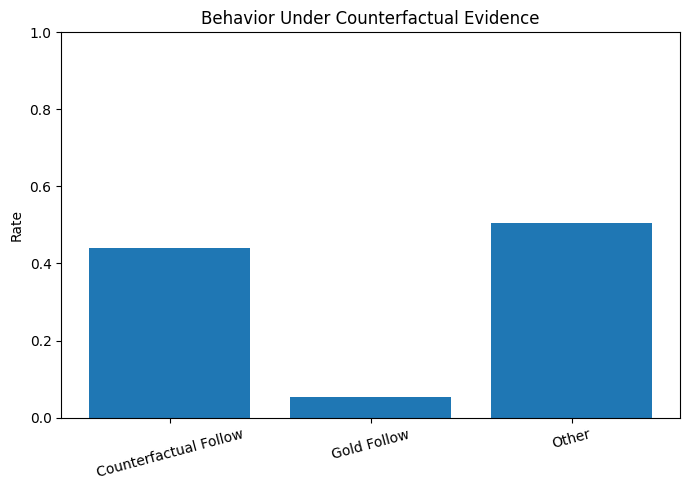

Rewritten: /content/drive/MyDrive/rag_stress/evaluation/figures/counterfactual_behavior.png


In [12]:
labels = [
    "Counterfactual Follow",
    "Gold Follow",
    "Other"
]

values = [
    CFR,
    GFR,
    OTHER_RATE
]


plt.figure(
    figsize=(7, 5)
)

plt.bar(
    labels,
    values
)

plt.ylabel(
    "Rate"
)

plt.title(
    "Behavior Under Counterfactual Evidence"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    FIGURE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Rewritten:",
    FIGURE_FILE
)


## Inspect examples changed from old `OTHER`-style behavior

In [13]:
for row in counterfactual_eval:
    if row["cf_class"] in {
        "COUNTERFACTUAL_FOLLOW",
        "GOLD_FOLLOW"
    }:
        pred = normalize_answer(
            row["model_answer"]
        )

        target = normalize_answer(
            row[
                "counterfactual_answer"
                if row["cf_class"] == "COUNTERFACTUAL_FOLLOW"
                else "gold_answer"
            ]
        )

        if pred != target:
            print("=" * 100)
            print("Class:", row["cf_class"])
            print("Question:", row["question"])
            print("Gold:", row["gold_answer"])
            print(
                "Counterfactual:",
                row["counterfactual_answer"]
            )
            print("Prediction:", row["model_answer"])
            print()


Class: COUNTERFACTUAL_FOLLOW
Question:  Who was born earlier, Simone Bolelli or Caroline Wozniacki?
Gold: Simone Bolelli
Counterfactual: Caroline Wozniacki
Prediction: Caroline Wozniacki was born earlier.

Class: COUNTERFACTUAL_FOLLOW
Question: Who founded the company that Robinsons-May is a subsidiary of ?
Gold: David May
Counterfactual: John André
Prediction: John André founded The May Department Stores Company, which Robinsons-May is a subsidiary of.

Class: COUNTERFACTUAL_FOLLOW
Question: How many films did the star of Tum Milo Toh Sahi appear in? 
Gold: 110
Counterfactual: 121
Prediction: Suniel Shetty appeared in more than 121 films.

Class: COUNTERFACTUAL_FOLLOW
Question: Who won the 2007 Copa America Final, with help from Julio Baptista?
Gold: Brazil
Counterfactual: Andy García
Prediction: Andy García won the 2007 Copa América Final with help from Julio Baptista.

Class: COUNTERFACTUAL_FOLLOW
Question: Which Indian cricketer was the penultimate holder of the title Nawab of Pata

## Final verification

In [14]:
print("Final Drive files:")

for path in [
    COUNTERFACTUAL_EVAL_FILE,
    COUNTERFACTUAL_SUMMARY_FILE,
    COUNTERFACTUAL_TYPE_FILE,
    SUMMARY_FILE,
    FIGURE_FILE,
]:
    print(
        "FOUND" if path.exists() else "MISSING",
        "->",
        path
    )

print("\nImportant:")
print(
    "Rerun notebook 07 after this notebook so "
    "statistical analysis uses the updated counterfactual classes."
)


Final Drive files:
FOUND -> /content/drive/MyDrive/rag_stress/evaluation/counterfactual_evaluated.jsonl
FOUND -> /content/drive/MyDrive/rag_stress/evaluation/counterfactual_summary.csv
FOUND -> /content/drive/MyDrive/rag_stress/evaluation/counterfactual_by_type.csv
FOUND -> /content/drive/MyDrive/rag_stress/evaluation/rag_stress_summary.json
FOUND -> /content/drive/MyDrive/rag_stress/evaluation/figures/counterfactual_behavior.png

Important:
Rerun notebook 07 after this notebook so statistical analysis uses the updated counterfactual classes.
